# How do Penn SEAS and UIUC Grainger compare on alumni outcomes?

I used two files for this analysis:

- `penn_vs_uiuc_engineering_data_v3.csv` for the structured comparison data
- `penn_vs_uiuc_engineering_raw_data_v3.md` for context and interpretation

### My questions

1. How do starting salaries compare?
2. How do Penn SEAS salary outcomes change over time?
3. How do post-graduation outcomes differ?
4. What do the career pathways look like?
5. What does the ROI comparison suggest?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("penn_vs_uiuc_engineering_data_v3.csv")
df.head()

,Category,Metric,Penn SEAS,UIUC Grainger,Year/Cohort,Source,Notes
0,Salary - SEAS Trend,Avg starting salary Class of 2016,$87571,—,2016,Penn SEAS 2020 PDF (5-yr trend),SEAS-specific (employed grads only)
1,Salary - SEAS Trend,Avg starting salary Class of 2017,$90905,—,2017,Penn SEAS 2020 PDF (5-yr trend),NaN
2,Salary - SEAS Trend,Avg starting salary Class of 2018,$92284,—,2018,Penn SEAS 2020 PDF (5-yr trend),NaN
3,Salary - SEAS Trend,Avg starting salary Class of 2019,$99079,—,2019,Penn SEAS 2020 PDF (5-yr trend),NaN
4,Salary - SEAS Trend,Avg starting salary Class of 2020 (all SEAS),$100653,—,2020,Penn SEAS 2020 PDF,n=140 Penn


In [9]:
def money_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["—", "-", "nan", "None", ""]:
        return np.nan
    x = x.replace("$", "").replace(",", "").replace("~", "")
    m = re.search(r"-?\d+\.?\d*", x)
    return float(m.group()) if m else np.nan

def pct_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["—", "-", "nan", "None", ""]:
        return np.nan
    x = x.replace("%", "").replace("~", "")
    m = re.search(r"-?\d+\.?\d*", x)
    return float(m.group()) if m else np.nan

df.columns

Index(['Category', 'Metric', 'Penn SEAS', 'UIUC Grainger', 'Year/Cohort',
       'Source', 'Notes'],
      dtype='str')

## Q1) How do starting salaries compare?

I started with the most recent salary comparison because that is the clearest high-level outcome measure.

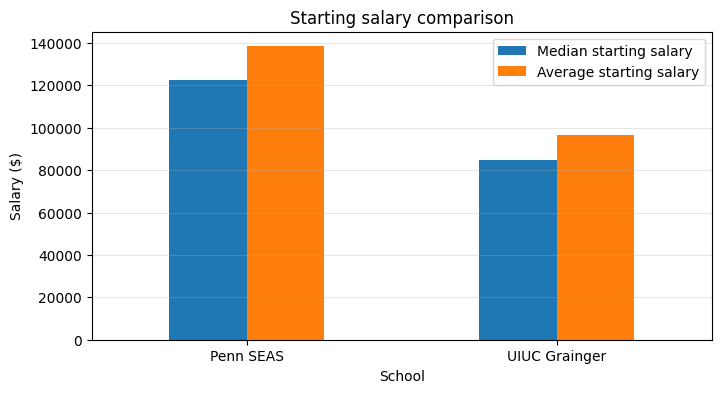

In [10]:
salary_compare = pd.DataFrame({
    "School": ["Penn SEAS", "UIUC Grainger"],
    "Median starting salary": [122500, 85000],
    "Average starting salary": [138360, 96766]
})

salary_compare.set_index("School").plot(kind="bar", figsize=(8,4))
plt.title("Starting salary comparison")
plt.ylabel("Salary ($)")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Penn SEAS has a clear salary advantage in the most recent comparison.

The median comparison matters more than the average comparison here. Penn reports a median of $122,500, while UIUC reports a median of $85,000. UIUC’s average is noticeably higher than its median, which suggests a right-skewed distribution where a smaller number of very high earners pull the mean upward.

So for a “typical graduate” comparison, the median gap is the better benchmark.

## Q2) How have Penn SEAS salaries changed over time?

Next, I looked at the Penn SEAS salary trend to see whether the most recent gap reflects a one-year anomaly or a broader pattern.

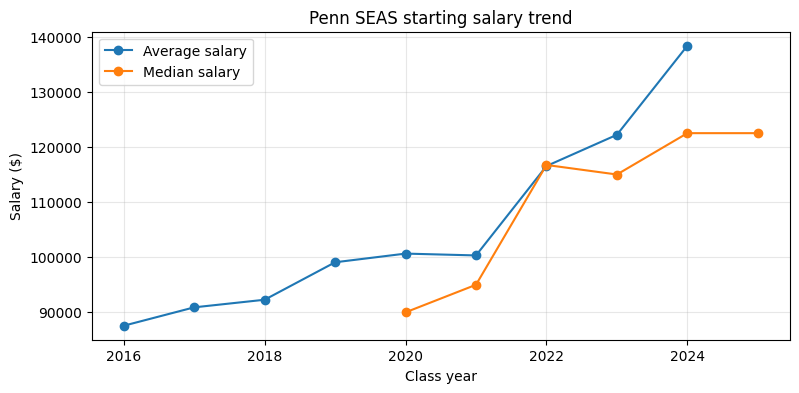

In [11]:
seas_trend = df[df["Category"] == "Salary - SEAS Trend"].copy()

avg_rows = seas_trend[seas_trend["Metric"].str.contains("Avg starting salary", case=False, na=False)].copy()
med_rows = seas_trend[seas_trend["Metric"].str.contains("Median starting salary", case=False, na=False)].copy()

avg_rows = avg_rows[avg_rows["Year/Cohort"].astype(str).str.fullmatch(r"\d{4}")]
med_rows = med_rows[med_rows["Year/Cohort"].astype(str).str.fullmatch(r"\d{4}")]

avg_rows["Year"] = avg_rows["Year/Cohort"].astype(int)
med_rows["Year"] = med_rows["Year/Cohort"].astype(int)

avg_rows["Penn Value"] = avg_rows["Penn SEAS"].apply(money_to_num)
med_rows["Penn Value"] = med_rows["Penn SEAS"].apply(money_to_num)

plt.figure(figsize=(9,4))
plt.plot(avg_rows["Year"], avg_rows["Penn Value"], marker="o", label="Average salary")
plt.plot(med_rows["Year"], med_rows["Penn Value"], marker="o", label="Median salary")
plt.title("Penn SEAS starting salary trend")
plt.xlabel("Class year")
plt.ylabel("Salary ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Penn SEAS salaries rise sharply after 2021, especially in 2022 and after.

That pattern lines up with what the raw notes suggest: stronger compensation in tech, finance, and consulting, plus a more recent shift toward quant and hedge fund placements that likely pushes the average up even more.

## Q3) How do post-graduation outcomes differ?

Salary is only one piece of the story, so I next compared where graduates actually go after finishing school.

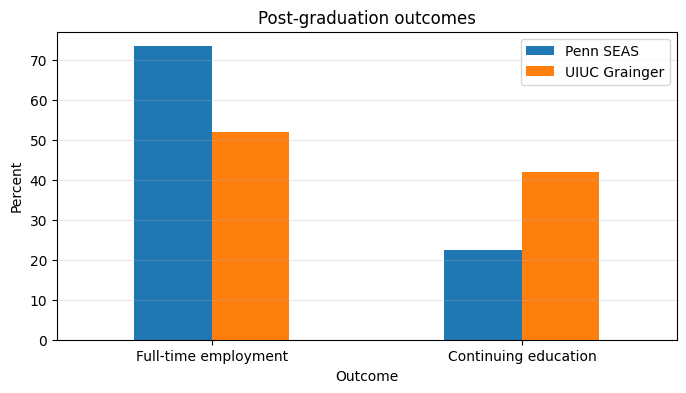

In [13]:
outcomes_compare = pd.DataFrame({
    "Outcome": ["Full-time employment", "Continuing education"],
    "Penn SEAS": [73.3, 22.3],
    "UIUC Grainger": [52.0, 42.0]
})

outcomes_compare.set_index("Outcome").plot(kind="bar", figsize=(8,4))
plt.title("Post-graduation outcomes")
plt.ylabel("Percent")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

The two schools have pretty different outcome structures.

Penn SEAS is much more oriented toward direct full-time placement, while UIUC sends a much larger share of graduates into further education. That means Penn’s economic payoff shows up faster, while UIUC’s pathway is more delayed and more academically oriented.

## Q4) What do the career pathways look like?

To understand why the salary gap exists, I looked at the kinds of industries each school seems to feed into.

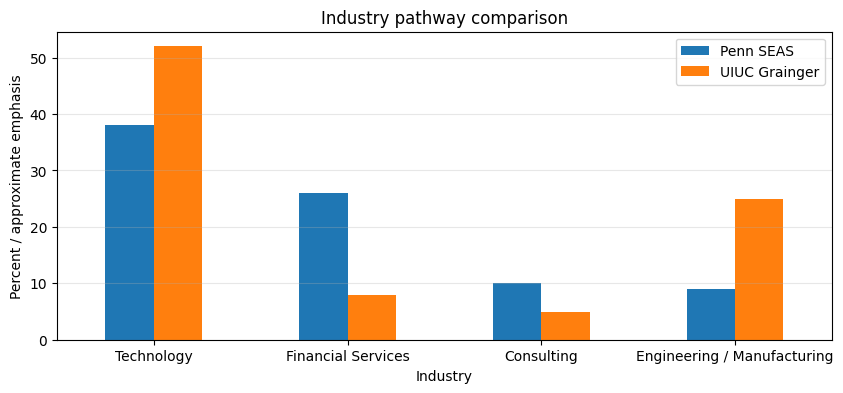

In [14]:
industry_compare = pd.DataFrame({
    "Industry": ["Technology", "Financial Services", "Consulting", "Engineering / Manufacturing"],
    "Penn SEAS": [38, 26, 10, 9],
    "UIUC Grainger": [52, 8, 5, 25]
})

industry_compare.set_index("Industry").plot(kind="bar", figsize=(10,4))
plt.title("Industry pathway comparison")
plt.ylabel("Percent / approximate emphasis")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

This is the main structural difference between the two schools.

Penn SEAS looks like a hybrid pipeline into tech, finance, and consulting. UIUC Grainger looks more like a traditional engineering and technical pipeline. That distinction helps explain why Penn graduates earn more immediately even though UIUC has the stronger pure engineering reputation.

## Q5) What does the ROI comparison suggest?

Finally, I used the cost and salary comparison to think about how quickly the Penn premium pays for itself.

In [15]:
penn_median_salary = 122500
uiuc_median_salary = 85000
salary_gap = penn_median_salary - uiuc_median_salary

net_cost_premium = 30000   # Penn vs UIUC in-state, aided basis
break_even_years = net_cost_premium / salary_gap

print("Median salary gap:", salary_gap)
print("Estimated break-even period:", round(break_even_years, 2), "years")

Median salary gap: 37500
Estimated break-even period: 0.8 years


On the assumptions in this dataset, Penn’s additional net cost versus UIUC in-state is earned back in less than a year of work.

That does not mean Penn is automatically “better” for every student, but it does show that if the goal is immediate earnings power, Penn’s salary advantage is large enough to outweigh the cost premium very quickly.

## Final takeaways

The main points are:

Penn SEAS has the stronger short-term earnings outcome, with a large advantage in median starting salary.

UIUC Grainger has the stronger pure engineering reputation, but a much larger share of students continue into graduate school, which delays immediate labor-market returns.

The biggest difference is not just prestige. It is pathway structure. Penn SEAS feeds more strongly into finance, consulting, and other high-paying front-office roles, while UIUC Grainger is more concentrated in traditional technical and engineering tracks.

So the schools are not just producing the same type of graduate at different salary levels. They are producing somewhat different outcome profiles.